#  Использование одномерных сверток в PyTorch

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann
* https://pytorch.org/docs/stable/generated/torch.nn.Conv1d.html
* https://pytorch.org/docs/stable/generated/torch.nn.MaxPool1d.html#torch.nn.MaxPool1d
* https://wandb.ai/wandb_fc/wb-tutorials/reports/Tutorial-Text-Classification-Using-CNNs--Vmlldzo0NTIxNDI5
* https://machinelearningmastery.com/how-to-develop-convolutional-neural-network-models-for-time-series-forecasting/

## Задачи для совместного разбора

1\. Изучите принцип работы одномерных сверточных слоев в `torch`

![1d conv](https://raw.githubusercontent.com/krzjoa/krzjoa.github.io/master/assets/img/2020-10-03-ts-and-torch-1/conv1d.gif)

![conv1d](https://www.macnica.co.jp/business/ai/blog/files/image5_2.png)

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Загрузите данные из файла `ts.csv`. Используя модель, состоящую из одного одномерного сверточного слоя, решите задачу предсказания $y_t$ по `k` предыдущим точкам временного ряда $x_{t-k}...x_{t-1}$. Исследуйте значения $k\in[1, 7]$. Для каждого $k$ выведите на экран итоговое значение функции потерь и веса ядра свертки. Визуализируйте исходный временной ряд и полученные прогнозы.

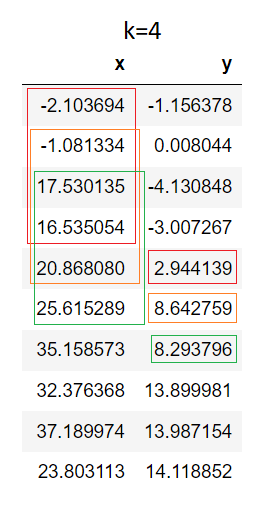
- [ ] Проверено на семинаре

In [ ]:
df = pd.read_csv('ts.csv')
df

,x,y
0,-2.103694,-1.156378
1,-1.081334,0.008044
2,17.530135,-4.130848
3,16.535054,-3.007267
4,20.868080,2.944139
...,...,...
1000,2.968320,20.707556
1001,3.323458,5.306192
1002,14.302680,-2.922816
1003,23.734496,1.263861


In [ ]:
series = df['x'].values
def prepare_data(series, k):
    inputs = []
    targets = []
    for i in range(k, len(series)):
        inputs.append(series[i-k:i])
        targets.append(series[i])
    return np.array(inputs), np.array(targets)

k=1:
   Final loss: 89.486214
   Kernel weights: ['0.9209']


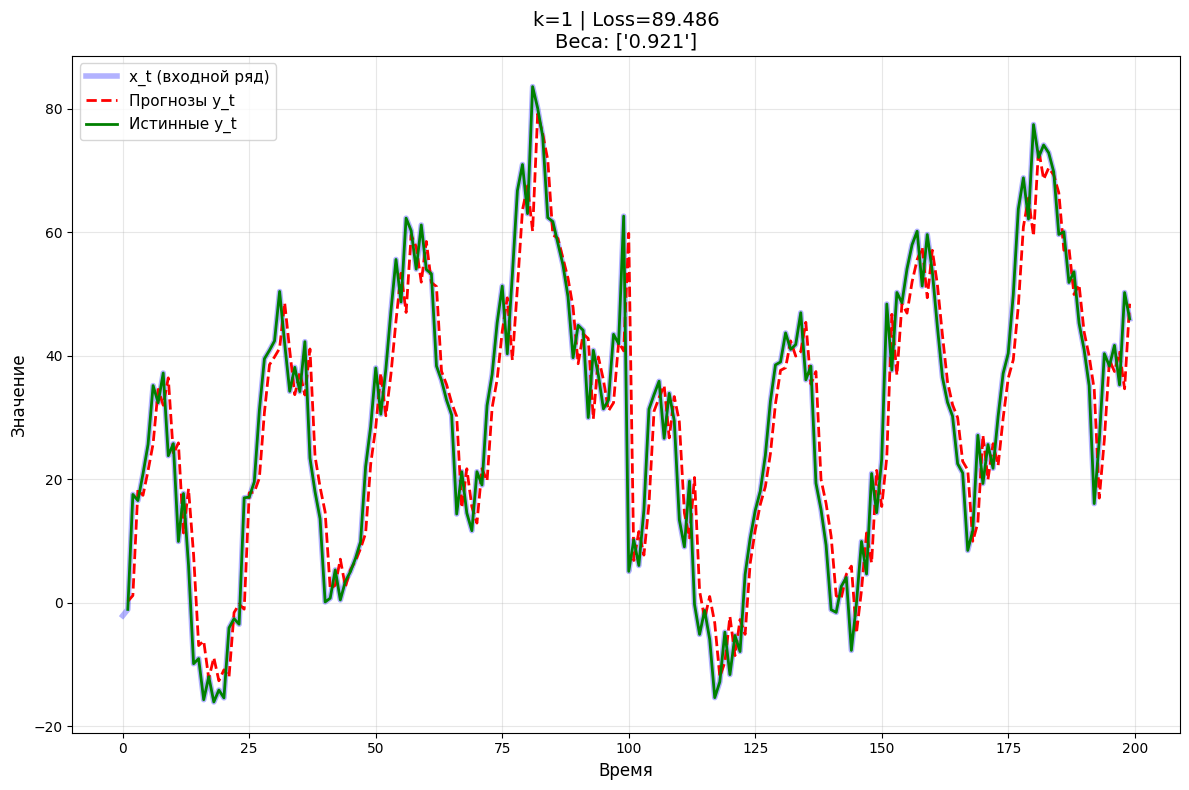

k=2:
   Final loss: 88.486382
   Kernel weights: ['0.1144', '0.8125']


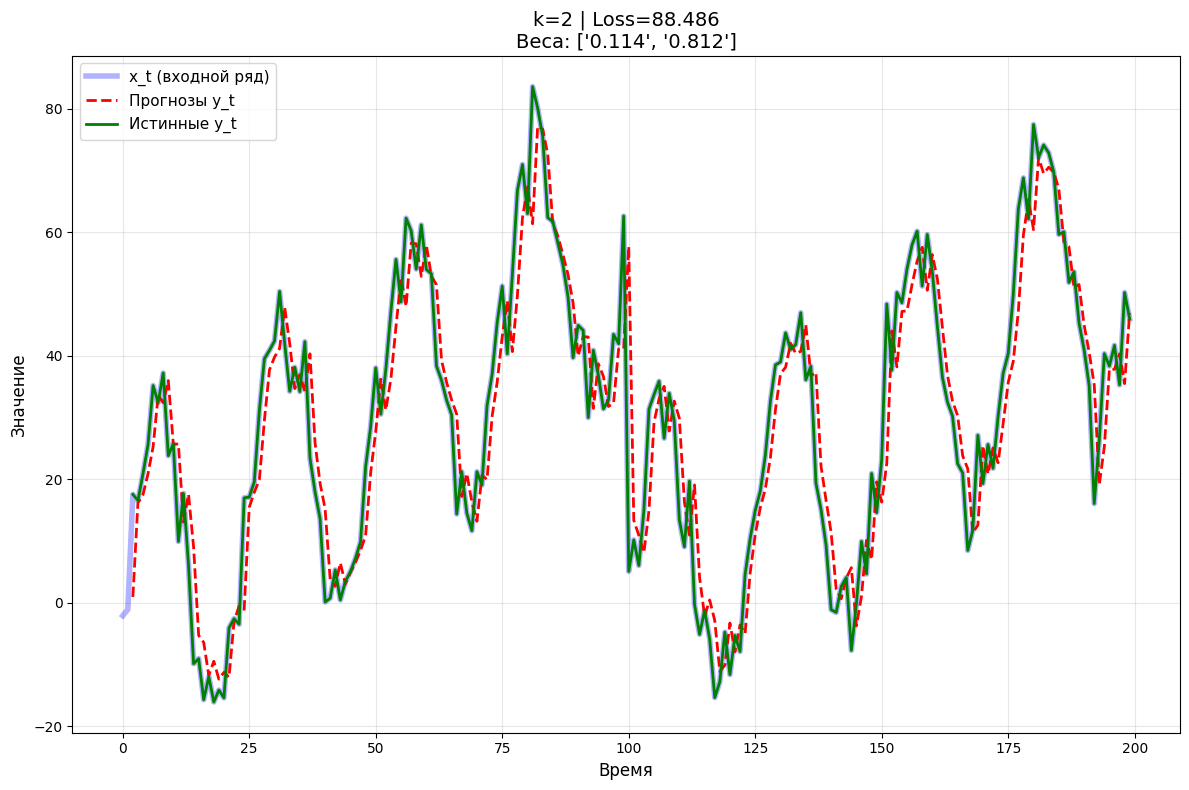

k=3:
   Final loss: 87.460030
   Kernel weights: ['-0.0638', '0.1375', '0.8654']


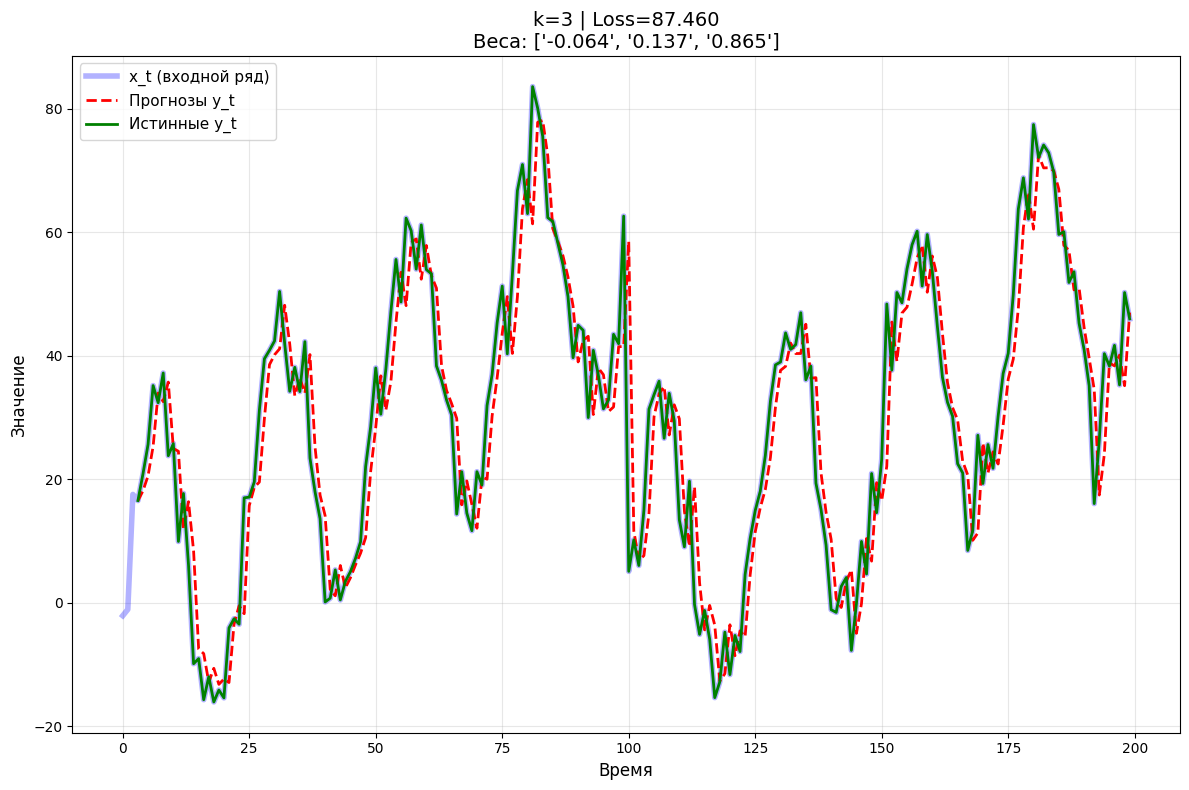

k=4:
   Final loss: 84.316811
   Kernel weights: ['-0.1355', '-0.0488', '0.2800', '0.8105']


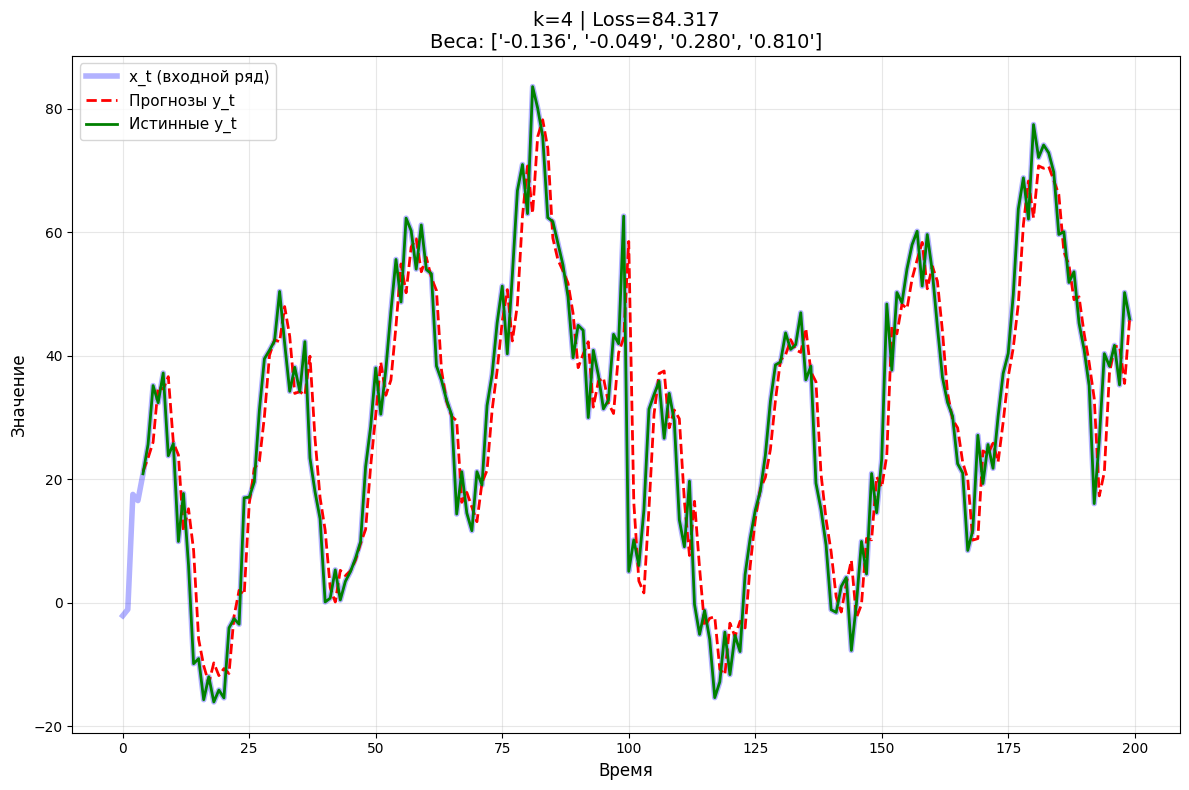

k=5:
   Final loss: 81.590202
   Kernel weights: ['-0.1766', '-0.0034', '0.0074', '0.2665', '0.7797']


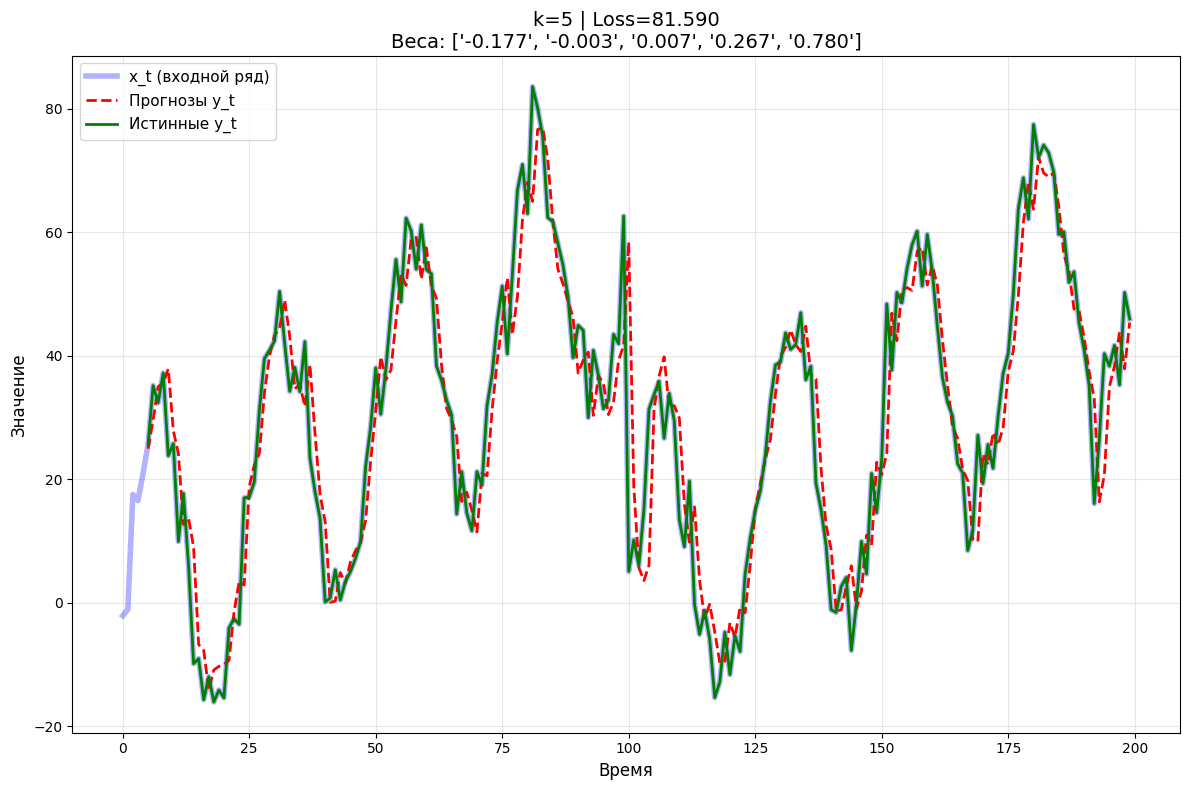

k=6:
   Final loss: 81.269135
   Kernel weights: ['-0.1335', '-0.0330', '-0.0155', '0.0307', '0.3106', '0.7420']


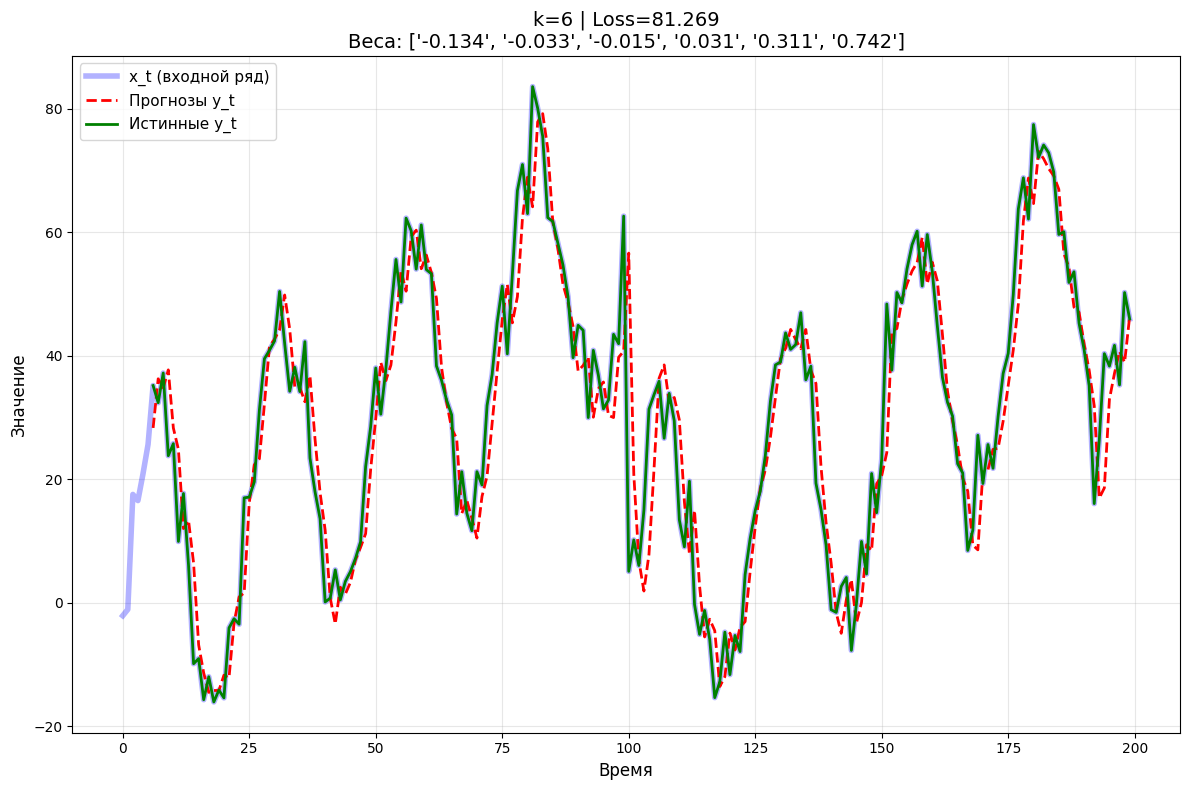

k=7:
   Final loss: 80.681389
   Kernel weights: ['-0.0156', '-0.1401', '-0.0281', '0.0437', '-0.0099', '0.2734', '0.7710']


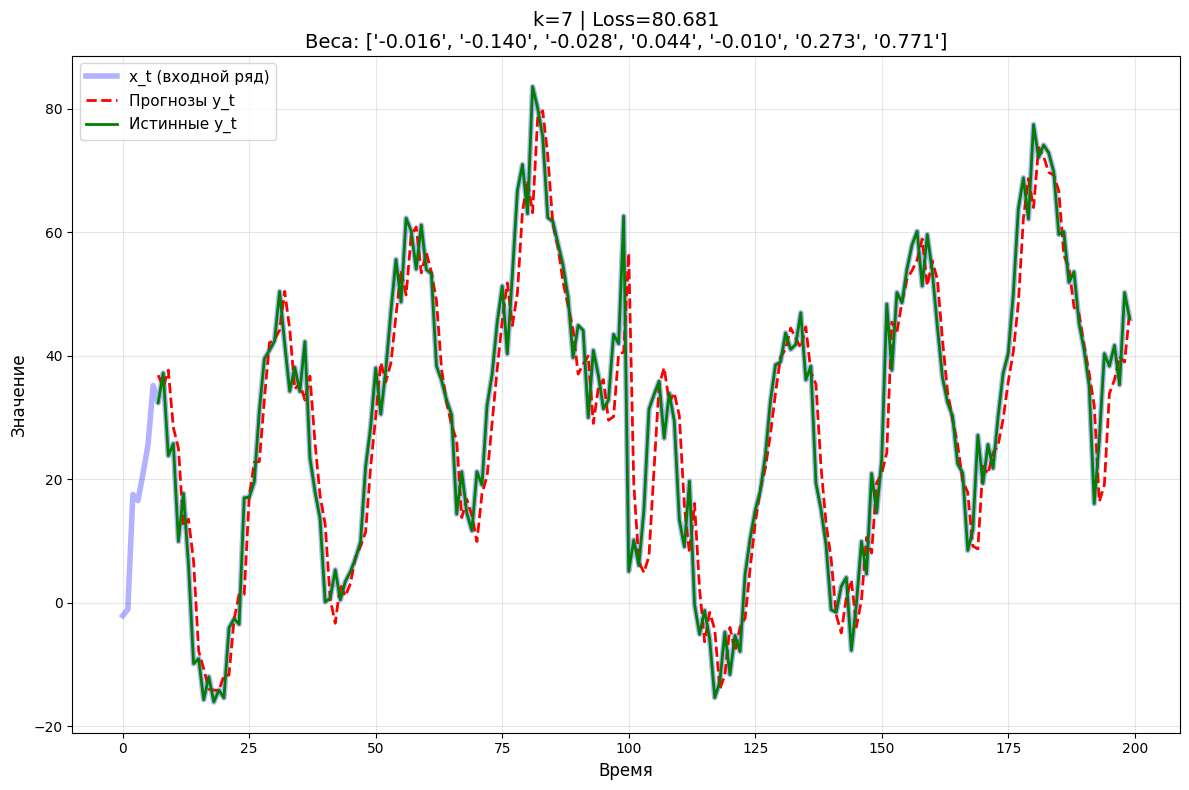

In [ ]:
results = []

for k in range(1, 8):
    inputs_np, targets_np = prepare_data(series, k)
    inputs = torch.from_numpy(inputs_np).float().unsqueeze(1)  # (N, 1, k)
    targets = torch.from_numpy(targets_np).float()

    model = nn.Conv1d(in_channels=1, out_channels=1, kernel_size=k)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()

    num_epochs = 1000
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs.squeeze(), targets)
        loss.backward()
        optimizer.step()

    final_loss = loss.item()
    weights = model.weight.data[0, 0, :].cpu().numpy()
    results.append((k, final_loss, weights))

    print(f'k={k}:')
    print(f'   Final loss: {final_loss:.6f}')
    print(f'   Kernel weights: {[f"{w:.4f}" for w in weights]}')

    with torch.no_grad():
        preds = model(inputs).squeeze().numpy()

    plt.figure(figsize=(12, 8))

    plot_length = min(200, len(series))
    num_preds_to_show = min(200 - k, len(preds))

    plt.plot(range(plot_length), series[:plot_length],
             'b-', linewidth=4, alpha=0.3, label='x_t (входной ряд)')

    if num_preds_to_show > 0:
        x_preds = range(k, k + num_preds_to_show)
        plt.plot(x_preds, preds[:num_preds_to_show],
                 'r--', linewidth=2, label='Прогнозы y_t')
        plt.plot(x_preds, targets_np[:num_preds_to_show],
                 'g-', linewidth=2, label='Истинные y_t')

    plt.title(f'k={k} | Loss={final_loss:.3f}\nВеса: {[f"{w:.3f}" for w in weights]}', fontsize=14)
    plt.xlabel('Время', fontsize=12)
    plt.ylabel('Значение', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
print("k\tLoss\t\tВеса ядра")

for k, loss, weights in results:
    weights_str = ', '.join([f"{w:.3f}" for w in weights])
    print(f"{k}\t{loss:.4f}\t[{weights_str}]")

best_k = min(results, key=lambda x: x[1])
print(f"\nОптимальное k={best_k[0]} с loss={best_k[1]:.4f}")

k	Loss		Веса ядра
1	89.4862	[0.921]
2	88.4864	[0.114, 0.812]
3	87.4600	[-0.064, 0.137, 0.865]
4	84.3168	[-0.136, -0.049, 0.280, 0.810]
5	81.5902	[-0.177, -0.003, 0.007, 0.267, 0.780]
6	81.2691	[-0.134, -0.033, -0.015, 0.031, 0.311, 0.742]
7	80.6814	[-0.016, -0.140, -0.028, 0.044, -0.010, 0.273, 0.771]

Оптимальное k=7 с loss=80.6814


<p class="task" id="2"></p>

2\. Загрузите файл `PV_Elec_Gas2.csv`. Опишите класс `ElectricityDataset`, который разбивает данные на окна в соответствии со следующей схемой:

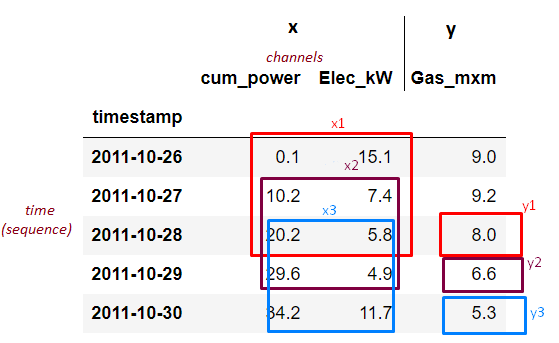

Разбейте набор данных на обучающую и тестовую выборку. Для теста оставьте данные за 2019 год.

- [ ] Проверено на семинаре

In [ ]:
df = pd.read_csv('PV_Elec_Gas2.csv')
df

,Unnamed: 0,cum_power,Elec_kW,Gas_mxm
0,2011-10-26,0.1,15.1,9.0
1,2011-10-27,10.2,7.4,9.2
2,2011-10-28,20.2,5.8,8.0
3,2011-10-29,29.6,4.9,6.6
4,2011-10-30,34.2,11.7,5.3
...,...,...,...,...
2943,2019-11-16,32231.0,12.0,15.0
2944,2019-11-17,32235.0,13.0,14.0
2945,2019-11-18,32238.0,13.0,14.0
2946,2019-11-19,32238.0,13.0,15.0


In [ ]:
df['timestamp'] = pd.to_datetime(df['Unnamed: 0'])
df = df.drop('Unnamed: 0', axis=1)

In [ ]:
X_features = ['cum_power', 'Elec_kW']
Y_feature = 'Gas_mxm'

X_df = df[X_features].values
Y_df = df[Y_feature].values
X_df.shape, Y_df.shape

((2948, 2), (2948,))

In [ ]:
class ElectricityDataset(Dataset):
    def __init__(self, X_data, Y_data, window_size=3):
        self.X_data = X_data
        self.Y_data = Y_data
        self.window_size = window_size
        self.num_samples = len(X_data) - window_size + 1

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        x_window = self.X_data[idx:idx + self.window_size]
        x = torch.tensor(x_window.T, dtype=torch.float32)
        y = torch.tensor(self.Y_data[idx + self.window_size - 1], dtype=torch.float32)
        return x, y

In [ ]:
test_start = pd.to_datetime('2019-01-01')
train_mask = df['timestamp'] < test_start
test_mask = df['timestamp'] >= test_start

X_train = X_df[train_mask]
Y_train = Y_df[train_mask]
X_test = X_df[test_mask]
Y_test = Y_df[test_mask]

print(f"Train: {len(X_train)} точек")
print(f"Test:  {len(X_test)} точек")

Train: 2624 точек
Test:  324 точек


In [ ]:
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

Y_train_scaled = scaler_Y.fit_transform(Y_train.reshape(-1, 1)).ravel()
Y_test_scaled = scaler_Y.transform(Y_test.reshape(-1, 1)).ravel()

In [ ]:
train_dataset = ElectricityDataset(X_train_scaled, Y_train_scaled, window_size=3)
test_dataset = ElectricityDataset(X_test_scaled, Y_test_scaled, window_size=3)

print(f"Train_dataset: {len(train_dataset)} окон")
print(f"Test_dataset:  {len(test_dataset)} окон")

Train_dataset: 2622 окон
Test_dataset:  322 окон


<p class="task" id="3"></p>

3\. Решите задачу предсказания столбца `Gas_mxm` на основе столбцов `cum_power` и `Elec_kW` с использованием одномерных сверток. Для оптимизации используйте мини-пакетный градиентный спуск с использованием `DataLoader`. Обратите внимание, что при создании `DataLoader` вы не можете перемешивать данные.

Постройте график изменения значения функции потерь на обучающем и тестовом множестве в зависимости от номера эпохи. Визуализируйте на одном графике прогнозы модели и предсказываемый временной ряд.

- [ ] Проверено на семинаре

In [ ]:
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
class ConvModel(nn.Module):
    def __init__(self):
        super(ConvModel, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=2, out_channels=32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 3, 16)
        self.fc2 = nn.Linear(16, 1)
        self.relu2 = nn.ReLU()

    def forward(self, x):
        out = self.conv1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.conv2(out)
        out = out.view(out.size(0), -1)  # (batch_size, 64 * 3)
        out = self.fc1(out)
        out = self.relu2(out)
        out = self.fc2(out)
        return out.squeeze(-1)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ConvModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.MSELoss()

In [ ]:
num_epochs = 200
train_losses = []
test_losses = []
best_test_loss = float('inf')
patience = 20
trigger_times = 0

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x_batch.size(0)
    train_loss /= len(train_dataset)
    train_losses.append(train_loss)

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            test_loss += loss.item() * x_batch.size(0)
    test_loss /= len(test_dataset)
    test_losses.append(test_loss)

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f'Раннее прекращение на эпохе {epoch + 1}')
            break

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')

Epoch [10/200], Train Loss: 0.3733, Test Loss: 0.3113
Epoch [20/200], Train Loss: 0.3696, Test Loss: 0.3043
Epoch [30/200], Train Loss: 0.3668, Test Loss: 0.3025
Epoch [40/200], Train Loss: 0.3612, Test Loss: 0.2921
Epoch [50/200], Train Loss: 0.3597, Test Loss: 0.2865
Epoch [60/200], Train Loss: 0.3517, Test Loss: 0.2752
Epoch [70/200], Train Loss: 0.3469, Test Loss: 0.2634
Epoch [80/200], Train Loss: 0.3523, Test Loss: 0.2621
Epoch [90/200], Train Loss: 0.3424, Test Loss: 0.2587
Epoch [100/200], Train Loss: 0.3436, Test Loss: 0.2602
Epoch [110/200], Train Loss: 0.3421, Test Loss: 0.2719
Раннее прекращение на эпохе 117


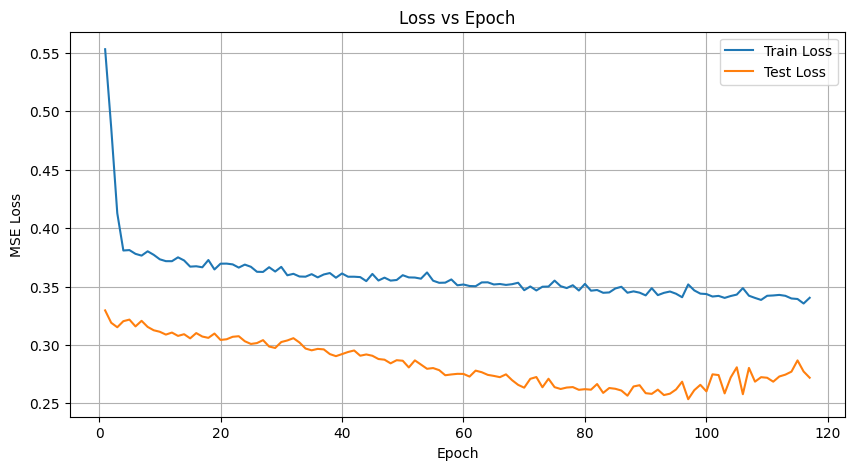

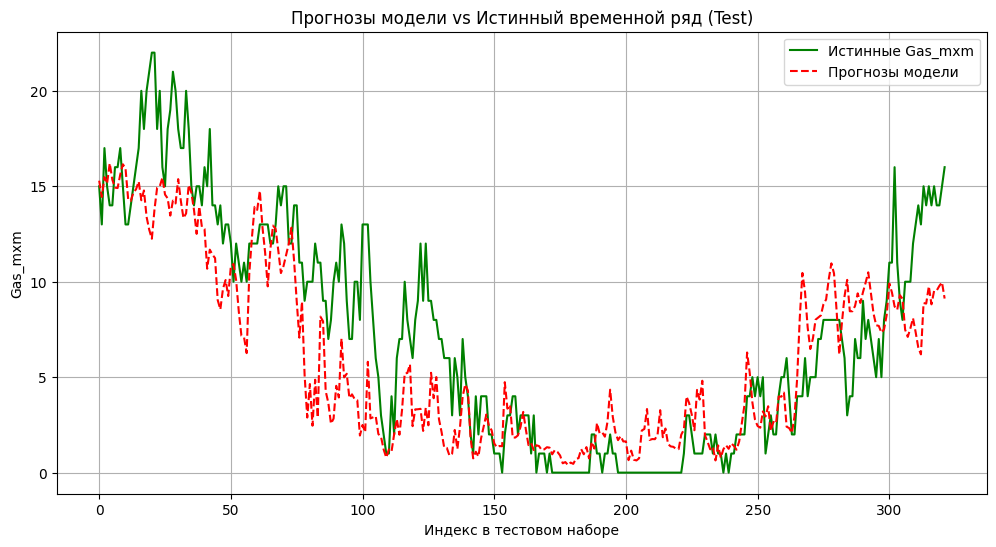

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss')
plt.plot(range(1, len(test_losses) + 1), test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

model.eval()
test_preds = []
test_indices = list(range(len(test_dataset)))
with torch.no_grad():
    for idx in test_indices:
        x, _ = test_dataset[idx]
        x = x.unsqueeze(0).to(device)
        pred = model(x)
        test_preds.append(pred.cpu().item())

test_preds_original = scaler_Y.inverse_transform([[p] for p in test_preds]).ravel()
test_true_original = scaler_Y.inverse_transform(Y_test_scaled[2:].reshape(-1, 1)).ravel()

plt.figure(figsize=(12, 6))
plt.plot(test_true_original, label='Истинные Gas_mxm', color='green')
plt.plot(test_preds_original, label='Прогнозы модели', color='red', linestyle='--')
plt.xlabel('Индекс в тестовом наборе')
plt.ylabel('Gas_mxm')
plt.title('Прогнозы модели vs Истинный временной ряд (Test)')
plt.legend()
plt.grid(True)
plt.show()

<p class="task" id="4"></p>

4\. Считайте файлы `polarity/positive_reviews.txt` (положительные обзоры на фильмы) и `polarity/negative_reviews.txt` (отрицательные обозоры на фильмы) и разбейте на обучающую и тестовую выборку. Выполните предобработку текста и создайте Vocab на основе обучающей выборки (токен - слово). Выведите на экран количество токенов в полученном словаре.

Создайте класс `PolarityDataset` и реализуйте метод `__getitem__` таким образом, чтобы он возвращал набор индексов токенов (слов) для текста и метки классов для этих текстов. Создайте два объекта класса `PolarityDataset` для обучающей и тестовой выборки. Выведите на экраны количество элементов и распределение данных по классам в каждом из них.

- [ ] Проверено на семинаре

In [ ]:
import numpy as np
from torch.utils.data import Dataset
from collections import Counter
import re
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
def load_reviews(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        return [line.strip() for line in f if line.strip()]

positive_reviews = load_reviews('positive_reviews.txt')
negative_reviews = load_reviews('negative_reviews.txt')

In [ ]:
positive_split = int(0.8 * len(positive_reviews))
negative_split = int(0.8 * len(negative_reviews))

positive_train = positive_reviews[:positive_split]
positive_test = positive_reviews[positive_split:]
negative_train = negative_reviews[:negative_split]
negative_test = negative_reviews[negative_split:]

In [ ]:
def preprocess_text(text):
    # Приведение к нижнему регистру и удаление спецсимволов
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text.split()

In [ ]:
all_train_texts = positive_train + negative_train
preprocessed_train_texts = [preprocess_text(text) for text in all_train_texts]

In [ ]:
word_counts = Counter(word for text in preprocessed_train_texts for word in text)
vocab = {word: idx + 1 for idx, (word, _) in enumerate(word_counts.items())}  # 0 для padding
vocab['<PAD>'] = 0  # Добавляем токен для паддинга
print(f"Количество токенов в словаре: {len(vocab)}")

Количество токенов в словаре: 18211


In [ ]:
from torch.utils.data import Dataset

class PolarityDataset(Dataset):
    def __init__(self, reviews, labels, vocab, window_size=3):
        self.reviews = reviews
        self.labels = labels
        self.vocab = vocab
        self.window_size = window_size
        self.preprocessed_reviews = [preprocess_text(review) for review in reviews]
        self.data = self._create_dataset()

    def _create_dataset(self):
        data = []
        for tokens in self.preprocessed_reviews:
            #каждое слово в индекс
            indices = [self.vocab.get(word, 0) for word in tokens]
            data.append(indices)
        return data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Возвращаем индексы токенов и метку
        return torch.tensor(self.data[idx], dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.float32)

In [ ]:
train_reviews = positive_train + negative_train
test_reviews = positive_test + negative_test
train_labels = [1] * len(positive_train) + [0] * len(negative_train)  # 1 для positive, 0 для negative
test_labels = [1] * len(positive_test) + [0] * len(negative_test)

train_dataset = PolarityDataset(train_reviews, train_labels, vocab)
test_dataset = PolarityDataset(test_reviews, test_labels, vocab)

In [ ]:
print(f"Train dataset size: {len(train_dataset)}")
print(f"Train class distribution: Positive = {train_labels.count(1)}, Negative = {train_labels.count(0)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Test class distribution: Positive = {test_labels.count(1)}, Negative = {test_labels.count(0)}")

Train dataset size: 8528
Train class distribution: Positive = 4264, Negative = 4264
Test dataset size: 2134
Test class distribution: Positive = 1067, Negative = 1067


In [ ]:
print(f"Positive reviews: {len(positive_reviews)}, Negative reviews: {len(negative_reviews)}")

Positive reviews: 5331, Negative reviews: 5331


<p class="task" id="5"></p>

5\. Решите задачу классификации текстов обзоров с использованием одномерных сверток. Для преобразования последовательности индексов в последовательность векторов используйте слой `nn.Embedding`. Обратите внимание, что `nn.Conv1d` ожидает на вход трехмерный тензор размерности `(batch, embedding_dim, seq_len)`. Выведите на экран отчет по классификации для обучающей и тестовой выборки после завершения процесса обучения. Добейтесь accuracy на тестовой выборке не менее 70%.

- [ ] Проверено на семинаре

In [ ]:
def get_predictions(loader, model, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for seqs, labels in loader:
            seqs, labels = seqs.to(device), labels.to(device).unsqueeze(1)
            outputs = model(seqs)
            preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy().flatten()
            all_preds.extend(preds.astype(int))
            all_labels.extend(labels.cpu().numpy().flatten().astype(int))
    return np.array(all_preds), np.array(all_labels)

In [ ]:
def make_confusion_matrix(loader, model, labels, device):
    preds, true = get_predictions(loader, model, device)
    cm = confusion_matrix(true, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix (Test Set — Best Model)')
    plt.show()

In [ ]:
CLASS_NAMES = ['Negative', 'Positive']

In [ ]:
from torch.nn.utils.rnn import pad_sequence
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau


def collate_fn(batch):
    sequences, labels = zip(*batch)
    sequences_padded = pad_sequence(sequences, batch_first=True, padding_value=0)
    labels = torch.stack(labels)
    return sequences_padded, labels


batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

In [ ]:
class ConvTextClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, output_dim):
        super(ConvTextClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.conv1 = nn.Conv1d(in_channels=embedding_dim, out_channels=32, kernel_size=3)
        self.bn1 = nn.BatchNorm1d(32)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(32, output_dim)
        self.dropout = nn.Dropout(0.6)

    def forward(self, x):
        embedded = self.embedding(x)  # (batch_size, seq_len, embedding_dim)
        embedded = embedded.permute(0, 2, 1)  # (batch_size, embedding_dim, seq_len)
        conv_out = self.conv1(embedded)  # (batch_size, 32, seq_len-2)
        conv_out = self.bn1(conv_out)
        conv_out = self.relu(conv_out)
        pooled = self.pool(conv_out)  # (batch_size, 32, 1)
        pooled = pooled.squeeze(-1)  # (batch_size, 32)
        out = self.dropout(pooled)
        out = self.fc(out)  # (batch_size, output_dim)
        return out

In [ ]:
vocab_size = len(vocab)
embedding_dim = 100
output_dim = 1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ConvTextClassifier(vocab_size, embedding_dim, output_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-2)
criterion = nn.BCEWithLogitsLoss()
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

In [ ]:
num_epochs = 100
train_losses = []
test_losses = []
best_test_acc = 0
patience = 10
trigger_times = 0
best_test_loss = float('inf')

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for sequences, labels in train_loader:
        sequences, labels = sequences.to(device), labels.to(device).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(sequences)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * sequences.size(0)
    train_loss /= len(train_dataset)
    train_losses.append(train_loss)

    model.eval()
    test_loss = 0.0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for sequences, labels in test_loader:
            sequences, labels = sequences.to(device), labels.to(device).unsqueeze(1)
            outputs = model(sequences)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * sequences.size(0)
            preds = torch.sigmoid(outputs) > 0.5
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    test_loss /= len(test_dataset)
    test_losses.append(test_loss)
    test_acc = (np.array(all_preds) == np.array(all_labels)).mean()
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        trigger_times = 0
        torch.save(model.state_dict(), "best_text_classifier_model.pth")
    else:
        trigger_times += 1
    if test_loss > best_test_loss + 0.05:
        print(f"Early stopping at epoch {epoch+1} due to Test Loss increase")
        break
    best_test_loss = min(best_test_loss, test_loss)
    if trigger_times >= patience:
        print(f"Early stopping at epoch {epoch+1} due to no accuracy improvement")
        break

    scheduler.step(test_loss)

    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}')

print(f"Best Test Accuracy: {best_test_acc:.4f}")

Epoch [5/100], Train Loss: 0.6903, Test Loss: 0.6767, Test Acc: 0.5881
Epoch [10/100], Train Loss: 0.6534, Test Loss: 0.6614, Test Acc: 0.6265
Epoch [15/100], Train Loss: 0.6381, Test Loss: 0.6505, Test Acc: 0.6485
Epoch [20/100], Train Loss: 0.6218, Test Loss: 0.6447, Test Acc: 0.6490
Epoch [25/100], Train Loss: 0.6128, Test Loss: 0.6391, Test Acc: 0.6495
Epoch [30/100], Train Loss: 0.5975, Test Loss: 0.6312, Test Acc: 0.6532
Epoch [35/100], Train Loss: 0.5771, Test Loss: 0.6215, Test Acc: 0.6617
Epoch [40/100], Train Loss: 0.5551, Test Loss: 0.6109, Test Acc: 0.6668
Epoch [45/100], Train Loss: 0.4980, Test Loss: 0.5697, Test Acc: 0.7142
Epoch [50/100], Train Loss: 0.4072, Test Loss: 0.5560, Test Acc: 0.7268
Epoch [55/100], Train Loss: 0.2912, Test Loss: 0.5705, Test Acc: 0.7324
Early stopping at epoch 59 due to Test Loss increase
Best Test Accuracy: 0.7441



Classification Report for Train Set:
              precision    recall  f1-score   support

    Negative       0.98      0.97      0.98      4264
    Positive       0.97      0.98      0.98      4264

    accuracy                           0.98      8528
   macro avg       0.98      0.98      0.98      8528
weighted avg       0.98      0.98      0.98      8528


Classification Report for Test Set:
              precision    recall  f1-score   support

    Negative       0.73      0.69      0.71      1067
    Positive       0.71      0.75      0.73      1067

    accuracy                           0.72      2134
   macro avg       0.72      0.72      0.72      2134
weighted avg       0.72      0.72      0.72      2134



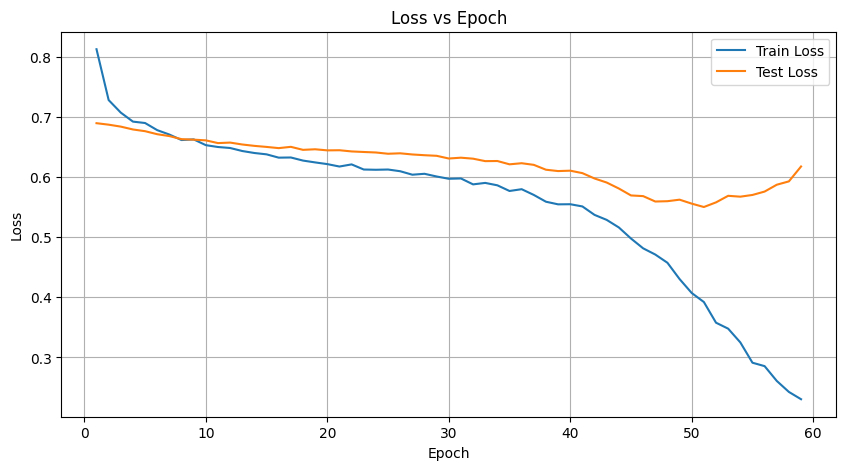

In [ ]:
print("\nClassification Report for Train Set:")
model.eval()
train_preds = []
train_labels_list = []
with torch.no_grad():
    for sequences, labels in train_loader:
        sequences, labels = sequences.to(device), labels.to(device).unsqueeze(1)
        outputs = model(sequences)
        preds = torch.sigmoid(outputs) > 0.5
        train_preds.extend(preds.cpu().numpy())
        train_labels_list.extend(labels.cpu().numpy())

print(classification_report(train_labels_list, train_preds, target_names=['Negative', 'Positive']))

print("\nClassification Report for Test Set:")
print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))

# Графики
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss')
plt.plot(range(1, len(test_losses) + 1), test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

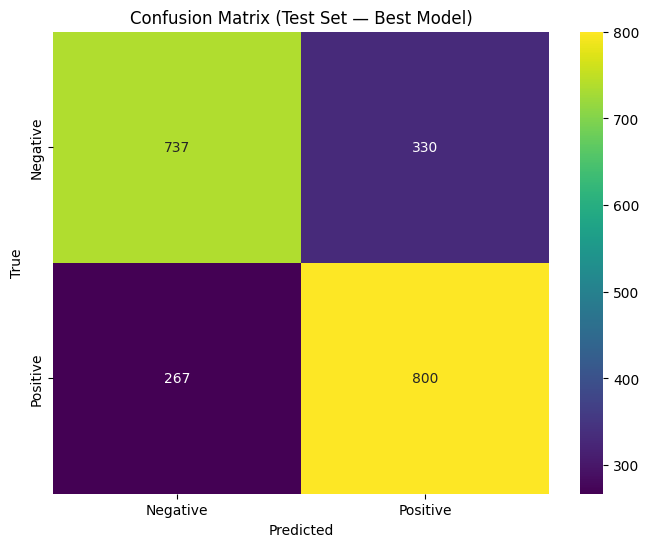

In [ ]:
make_confusion_matrix(test_loader, model, CLASS_NAMES, device)

<p class="task" id="6"></p>

6\. Придумайте небольшой отзыв, прогоните его через модель и выведите метку предсказанного класса (позитивный или негативный). Сделайте это для явно позитивного и явно негативного отзыва.

- [ ] Проверено на семинаре

In [ ]:
import torch
import re

def predict_review(model, vocab, review_text, device):
    def preprocess_text(text):
        text = text.lower()
        text = re.sub(r'[^\w\s]', '', text)
        return text.split()

    tokens = preprocess_text(review_text)
    indices = [vocab.get(word, 0) for word in tokens]  # 0 для неизвестных слов
    sequence = torch.tensor(indices, dtype=torch.long).unsqueeze(0)  # (1, seq_len)

    max_len = max([len(x) for x in train_dataset.data]) if hasattr(train_dataset, 'data') else 100
    if len(indices) > max_len:
        sequence = sequence[:, :max_len]
    elif len(indices) < max_len:
        padding = torch.zeros(1, max_len - len(indices), dtype=torch.long)
        sequence = torch.cat((sequence, padding), dim=1)

    model.eval()
    with torch.no_grad():
        sequence = sequence.to(device)
        output = model(sequence)
        prediction = torch.sigmoid(output) > 0.5
        return "Positive" if prediction.item() == 1 else "Negative"

positive_review = "Perfect dress!"
negative_review = "I can't stand it!"

print(f"Positive review: '{positive_review}'")
print(f"Predicted class: {predict_review(model, vocab, positive_review, device)}\n")

print(f"Negative review: '{negative_review}'")
print(f"Predicted class: {predict_review(model, vocab, negative_review, device)}")

Positive review: 'Perfect dress!'
Predicted class: Positive

Negative review: 'I can't stand it!'
Predicted class: Negative


## Обратная связь
- [ ] Хочу получить обратную связь по решению